### **RealSyn**

In [110]:
COCO = {
    
    'sheep': [772, 1554, 3926, 12953, 16520, 17890, 27438, 30314, 31451, 31678, 38365, 38552, 40961, 42254, 45496, 46418, 46760, 51844, 52563, 58933, 59393, 
              60117, 62875, 63182, 64588, 69777, 70334, 84356, 86615, 88029, 92942, 99165, 102614, 103819, 105478, 106151, 112128, 119469, 122137, 124230, 125872, 
              128311, 131093, 132470, 134946, 138618, 140729, 145135, 145912, 149253, 159072, 165969, 167342, 180021, 181934, 186009, 187334, 187351, 187540, 190776, 
              190929, 192450, 195159, 197461, 200541, 206397, 209275, 213005, 213860, 215289, 219778, 221674, 226345, 234993, 238748, 239181, 241292, 243316, 249264, 
              250745, 252919, 253307, 261617, 266207, 271185, 272162, 273052, 274599, 275817, 281323, 281634, 286770, 287907, 296573, 299042, 308235, 311075, 314189, 
              319866, 325346, 327218, 337256, 342296, 345244, 345590, 348204, 353562, 359234, 365469, 367695, 369367, 370266, 370609, 371029, 373196, 
              373317, 377911, 378764, 380693, 382453, 382500, 386785, 390943, 391018, 393844, 399957, 402191, 404972, 413260, 413757, 414067, 417887, 422284, 424289, 
              424633, 425032, 425398, 426427, 427133, 427643, 431315, 431335, 434263, 435653, 436797, 438439, 444651, 445141, 447711, 452454, 454959, 455476, 463805, 
              468416, 477828, 484062, 488374, 492658, 499302, 503575, 504730, 508430, 509693, 510493, 511496, 512879, 513968, 515695, 517148, 518695, 524648, 525591, 
              528130, 528165, 536540, 540680, 543797, 545478, 548619, 551832, 553371, 557150, 557907, 558194, 562110, 573961, 578154, 578649, 579885],
    
    'cow': [8457, 8595, 8612, 15823, 17602, 22983, 23908, 24480, 29341, 37011, 43683, 62220, 66118, 83656, 96044, 99983, 103257, 104435, 121340, 127475, 135800, 137706, 
            214676, 221509, 226973, 237622, 283589, 352243, 407423, 429092, 429509, 515296, 532043, 545305, 572355],

    'horse': [5612, 21510, 23033, 56303, 56891, 68490, 74460, 86442, 92711, 114677, 125898, 139561, 142318, 149257, 150098, 158754, 165232, 175739, 186626, 202672, 
              204087, 209320, 212629, 214926, 215243, 223228, 224845, 226258, 234957, 247228, 266631, 272953, 290957, 299533, 303267, 312631, 318814, 332556, 340478, 
              346388, 352290, 352755, 354075, 354491, 356641, 365451, 369849, 371194, 382172, 388777, 393677, 402362, 404854, 415588, 439124, 449132, 453442, 464633, 
              472841, 489266, 489906, 492469, 512467, 513918, 519489, 546690, 550448, 569065]
}

VISUAL


In [2]:
def mask_on_top(image1, mask,  image2=None, save_path: str=None, verbose=False, titles=["Image1", "Image2"], fig_size=(15, 5)):

    fig, axes = plt.subplots(1, 2, figsize=fig_size)

    plt.figure(figsize=(5, 5))
    
    if image2 is not None:  
        axes[0].imshow(image2)
        axes[0].imshow(mask, cmap='viridis', alpha=0.5) 
    else: 
        axes[0].imshow(image1)
    axes[0].axis('off') 
    axes[0].set_title(titles[0])

    axes[1].imshow(image1)  
    axes[1].imshow(mask, cmap='viridis', alpha=0.5)  
    axes[1].axis('off') 
    axes[1].set_title(titles[1])

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    if verbose:     
        plt.show()

### Blending

- Direct Paste
- Poisson
- Feathered GaussianBlur
- Pyramid

In [3]:
import numpy as np
import cv2
from skimage.morphology import disk
from skimage.filters import median

import matplotlib.pyplot as plt
import random

from data.coco_dataloader import *
from visualizations import *

import glob

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import cv2
import numpy as np

#### older

In [6]:
good_images = sorted(glob.glob(os.path.join("/home/maria/Documents/dataset_splited/agco_dataset/train/", "good", "*.png")))

In [7]:
# '/home/maria/Documents/dataset_splited/agco_dataset/train/good/BNV61080I3001136_cam_lucid_490_image_raw_2024_06_24_14_28_37_124.png'

#dest_img = cv2.imread(good_images[16])
#dest_img = cv2.cvtColor(dest_img, cv2.COLOR_BGR2RGB)

#y_range, x_range = dest_img.shape[:2] #np.where(dest_mask > 0)
#y_centre, x_centre = ((y_range-0)//2)+1, ((x_range-0)//2)+1

#print(y_centre, x_centre)

#plt.imshow(destination_image)
#dest_mask = field_mask(dest_img, y_centre=y_centre)
#mask_on_top(dest_img, dest_mask)

In [4]:
#### RealSyn ####
# 1. Sample a COCO image based on a label or randomly

# 2. Find a Subtable location on the image where the resized object can be placed
    # [OK] 1. Define a offset to create a mask of where the the object can be placed.
    # 2. Resample a centre using uniform distribution
    # 3. Rescale the object using a pre-defined re-scaling range
    # 4. Resample a new center, if needed or cut off part of the object
    # 5. Checks if the object overlaps with the mask in at least min_overlap

# 3. Use three blending techniques

# 4. Decide which one is best based on the combination of metrics

### 1.Sample a COCO image based on a label or randomly

In [108]:
COCO_DATA_DIR = '/home/maria/Documents/datasets/coco2017'
COCO_DATA_TYPE = 'train2017' # 'val2017' # 'test2017'
CLASS = 'sheep'

coco_info, img_ids = get_coco_ids(data_dir=COCO_DATA_DIR, data_type=COCO_DATA_TYPE, cls=CLASS)

loading annotations into memory...
Done (t=102.26s)
creating index...
index created!


In [113]:
## read the index and save the image and the mask
DATA_PATH_TO = "/home/maria/Documents/datasets/coco_anomaly/"
for INDEX in range(len(COCO[CLASS])):
    source_image, source_mask = load_image_by_id(coco=coco_info, img_ids=img_ids, data_dir=COCO_DATA_DIR, data_type=COCO_DATA_TYPE, cls=CLASS, specific_id=COCO[CLASS][INDEX])

    cv2.imwrite(f"{DATA_PATH_TO}/{CLASS}/{COCO[CLASS][INDEX]}_mask.png", source_mask*255.)
    plt.imsave(f"{DATA_PATH_TO}/{CLASS}/{COCO[CLASS][INDEX]}_source.png", source_image)

Image ID: 772, File: 000000000772.jpg
Labels found in this image: ['sheep', 'sheep', 'sheep']
Image ID: 1554, File: 000000001554.jpg
Labels found in this image: ['sheep', 'sheep', 'sheep']
Image ID: 3926, File: 000000003926.jpg
Labels found in this image: ['sheep', 'sheep']
Image ID: 12953, File: 000000012953.jpg
Labels found in this image: ['sheep', 'sheep', 'sheep']
Image ID: 16520, File: 000000016520.jpg
Labels found in this image: ['sheep']
Image ID: 17890, File: 000000017890.jpg
Labels found in this image: ['sheep', 'sheep']
Image ID: 27438, File: 000000027438.jpg
Labels found in this image: ['sheep', 'sheep']
Image ID: 30314, File: 000000030314.jpg
Labels found in this image: ['sheep', 'sheep', 'sheep']
Image ID: 31451, File: 000000031451.jpg
Labels found in this image: ['sheep', 'sheep', 'sheep']
Image ID: 31678, File: 000000031678.jpg
Labels found in this image: ['sheep', 'sheep', 'sheep', 'sheep', 'sheep']
Image ID: 38365, File: 000000038365.jpg
Labels found in this image: ['s

In [ ]:
plt.imsave()

Image ID: 27438, File: 000000027438.jpg
Labels found in this image: ['sheep', 'sheep']


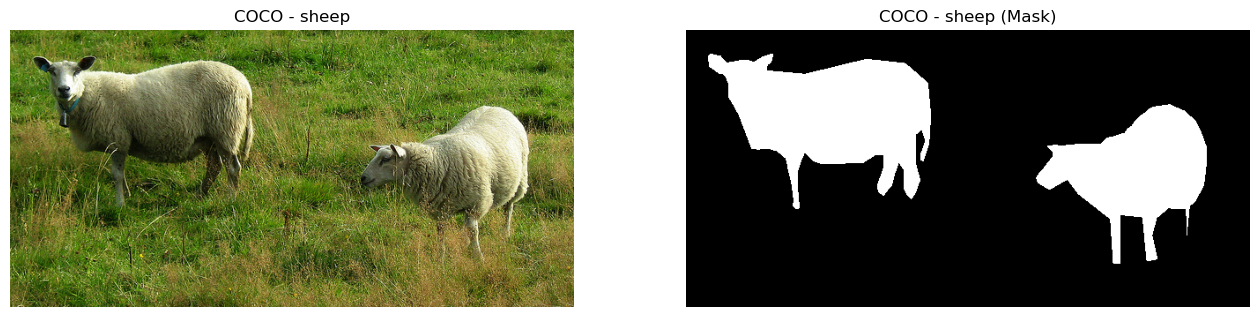

In [ ]:
INDEX = 6 # sheep [300, 700], 115
#for INDEX in range(len(COCO[CLASS])):
source_image, source_mask = load_image_by_id(coco=coco_info, img_ids=img_ids, data_dir=COCO_DATA_DIR, data_type=COCO_DATA_TYPE, cls=CLASS, specific_id=COCO[CLASS][INDEX])

#print(source_image.shape)

#display_images_side_by_side(images=[source_image, source_mask], titles=[f"COCO - {CLASS}", f"COCO - {CLASS} (Mask)"], config_cmap=[None, 'grey'], save_path=None)

# RealSyn

## Location Sampling and Object Resizing

### 1. Define the region where the object can be placed. To help with this we will create a mask.

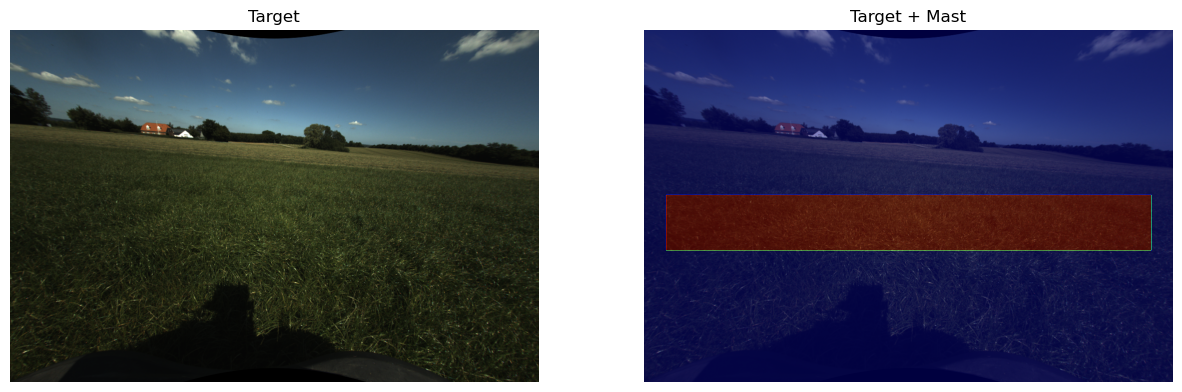

In [107]:
def field_mask(dest_image, y_centre):

    height, width = dest_image.shape[:2]

    x1, y1 = 50, y_centre-25
    x2, y2 = width - 50, y_centre + 100

    mask = np.zeros((height, width), dtype=np.uint8)

    cv2.rectangle(mask, (x1, y1), (x2, y2), 1, thickness=cv2.FILLED)

    return mask

good_images = sorted(glob.glob(os.path.join("/home/maria/Documents/dataset_splited/agco_dataset/train/", "good", "*.png")))

dest_img = cv2.imread(good_images[16])
dest_img = cv2.cvtColor(dest_img, cv2.COLOR_BGR2RGB)
# creating the mask
h = dest_img.shape[0] 
middle_point_y = ((h)//2)+1
dest_mask = field_mask(dest_image=dest_img, y_centre=middle_point_y)

#visualize, save
mask_on_top(image1=dest_img, mask=dest_mask,  image2=None, save_path=None, verbose=False, titles=["Target", "Target + Mast"], fig_size=(15, 5))

### 2. Resize the object. 

#### a. For this a bbox will be cropped around the object so we can get its size approximately 

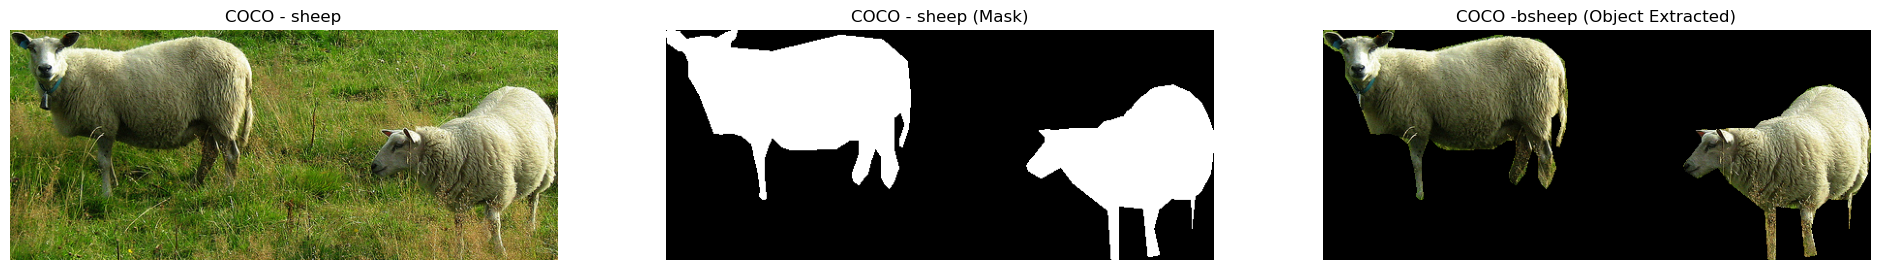

In [93]:
def get_bbox_extraction(src_mask, src_image):
    
    contours, _ = cv2.findContours(src_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    x_min, y_min, x_max, y_max = float('inf'), float('inf'), 0, 0

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        x_min = min(x_min, x)
        y_min = min(y_min, y)
        x_max = max(x_max, x + w)
        y_max = max(y_max, y + h)

    #bounding_box = (x_min, y_min, x_max - x_min, y_max - y_min)

    mask_with_bbox = cv2.cvtColor(src_mask, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(mask_with_bbox, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

    cropped_mask = src_mask[y_min:y_max, x_min:x_max]
    cropped_image = src_image[y_min:y_max, x_min:x_max]

    object_extracted = cv2.bitwise_and(cropped_image, cropped_image, mask=cropped_mask)

    return cropped_mask, cropped_image, object_extracted

cropped_mask, cropped_image, object_extracted = get_bbox_extraction(src_mask=source_mask, src_image=source_image)

display_images_side_by_side(images=[cropped_image, cropped_mask, object_extracted], titles=[f"COCO - {CLASS}", f"COCO - {CLASS} (Mask)", f"COCO -b{CLASS} (Object Extracted)"], config_cmap=[None, 'grey', None], save_path=None)

#### b. After sample a scale_fator from a normal distribution.

In [94]:
def calculate_resize_parameters(min_target_height, max_target_height, original_height):

    mean = (min_target_height + max_target_height) / 2
    std_dev = (max_target_height - min_target_height) / 4  # 95% within ±2σ

    heights = np.random.normal(mean, std_dev, 1000)
    heights = np.clip(heights, min_target_height, max_target_height)

    target_height = np.random.choice(heights)

    return target_height / original_height

def resize_object(src_image, src_mask):

    h, w = src_image.shape[:2]
    
    new_width = int(w * scale_factor)
    new_height = int(h * scale_factor)

    new_width = int(w * scale_factor)
    new_height = int(h * scale_factor)

    resized_object = cv2.resize(src_image, (new_width, new_height), interpolation=cv2.INTER_AREA)
    resized_mask = cv2.resize(src_mask, (new_width, new_height), interpolation=cv2.INTER_NEAREST)

    return resized_object, resized_mask

scale_factor = calculate_resize_parameters(min_target_height=250, max_target_height=400, original_height=cropped_image.shape[0])
print(scale_factor, cropped_image.shape[0])

resized_image, resized_mask = resize_object(src_image=cropped_image, src_mask=cropped_mask)
print(resized_image.shape[0])

# visualize, save
#display_images_side_by_side(images=[resized_image, resized_mask], titles=[f"COCO - {CLASS}", f"COCO - {CLASS} (Mask)"], config_cmap=[None, 'grey'], save_path=None)

1.4053390783644288 238
334


### 4. Find a sutable centre in the destination image

#### a. A normal destribution is used to sample `y_centre` and `x_centre`

469 394
0.5962525822390278 True


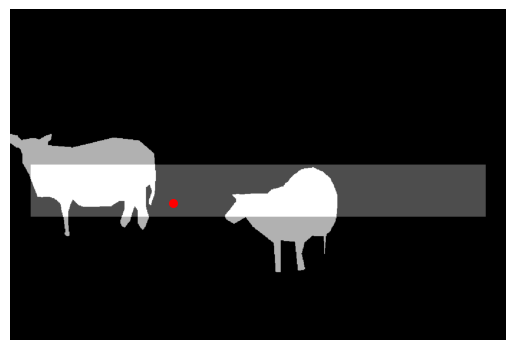

In [95]:
def get_placement_mask(src_img, src_mask, dest_img, y_centre, x_centre):
    
    patch_height, patch_width = src_img.shape[:2]
    dest_height, dest_width = dest_img.shape[:2]
    
    top_left_x = x_centre - patch_width // 2
    top_left_y = y_centre - patch_height // 2

    valid_top_left_x = max(top_left_x, 0)
    valid_top_left_y = max(top_left_y, 0)
    valid_bottom_right_x = min(top_left_x + patch_width, dest_width)
    valid_bottom_right_y = min(top_left_y + patch_height, dest_height)

    crop_left = max(0, -top_left_x)
    crop_top = max(0, -top_left_y)
    crop_right = crop_left + (valid_bottom_right_x - valid_top_left_x)
    crop_bottom = crop_top + (valid_bottom_right_y - valid_top_left_y)

    cropped_source = src_img[crop_top:crop_bottom, crop_left:crop_right]
    cropped_mask = src_mask[crop_top:crop_bottom, crop_left:crop_right]

    placement_mask = np.zeros(dest_img.shape[:2], dtype=np.uint8)
    placement_mask[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x] = cropped_mask

    placement_image = dest_img.copy() #np.zeros(dest_img.shape, dtype=np.uint8)
    placement_image[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x] = cropped_source

    return cropped_source, cropped_mask, placement_mask, placement_image

def check_contains_object(placement_mask, min_object_ratio, dest_mask):

    y_range, x_range = np.where(dest_mask > 0)

    obj_inside = placement_mask[y_range.min():y_range.max(), x_range.min():x_range.max()]
    
    object_pixels_inside = np.sum(obj_inside)
    object_pixels_outside = np.sum(placement_mask)
    total_pixels = (y_range.max()-y_range.min()) * (x_range.max()-x_range.min())
    object_ratio = object_pixels_inside / object_pixels_outside

    return object_ratio, object_ratio>=min_object_ratio

# sample a pair until it finds (constrain)
max_inter=200
contains=False
idx=0
while (not contains) and (idx < max_inter):
    y_range, x_range = np.where(dest_mask > 0)
    centre_y = random.randint(y_range[0], y_range[-1]) # H
    centre_x = random.randint(x_range[0], x_range[-1]) # W

    print(centre_y, centre_x)

    # crop the image if needed
    cropped_source, cropped_mask, placement_mask, placement_image = get_placement_mask(src_img=resized_image, src_mask=resized_mask, dest_img=dest_img, y_centre=centre_y, x_centre=centre_x)

    # check if at least 30% of the object is inside the 
    object_ratio, contains = check_contains_object(placement_mask=placement_mask, min_object_ratio=0.30, dest_mask=dest_mask)
    print(object_ratio, contains)

    idx += 1

plt.scatter(centre_x, centre_y, color='red', marker='o', s=30)
plt.imshow(dest_mask, cmap='grey')
plt.imshow(placement_mask, cmap='grey', alpha=0.7)
plt.axis('off')
plt.show()

In [96]:
cropped_mask.shape, dest_img.shape, cropped_source.shape

((334, 792), (800, 1200, 3), (334, 792, 3))

### Image Composition

#### Image Processing/Adjustiments

In [97]:
def color_transfer(src, dst):
    src_lab = cv2.cvtColor(src, cv2.COLOR_RGB2LAB)
    dst_lab = cv2.cvtColor(dst, cv2.COLOR_RGB2LAB)

    src_l, src_a, src_b = cv2.split(src_lab)
    dst_l, dst_a, dst_b = cv2.split(dst_lab)

    src_mean, src_std = [src_l.mean(), src_a.mean(), src_b.mean()], [src_l.std(), src_a.std(), src_b.std()]
    dst_mean, dst_std = [dst_l.mean(), dst_a.mean(), dst_b.mean()], [dst_l.std(), dst_a.std(), dst_b.std()]

    l = ((src_l - src_mean[0]) * (dst_std[0] / src_std[0])) + dst_mean[0]
    a = ((src_a - src_mean[1]) * (dst_std[1] / src_std[1])) + dst_mean[1]
    b = ((src_b - src_mean[2]) * (dst_std[2] / src_std[2])) + dst_mean[2]

    l = np.clip(l, 0, 255)
    a = np.clip(a, 0, 255)
    b = np.clip(b, 0, 255)

    transferred = cv2.merge((l.astype(np.uint8), a.astype(np.uint8), b.astype(np.uint8)))
    return cv2.cvtColor(transferred, cv2.COLOR_LAB2RGB)

def apply_clahe(image):

    image = (image * 255).clip(0, 255).astype(np.uint8)

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    lab_clahe = cv2.merge((cl, a, b))

    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

#### Direct Paste

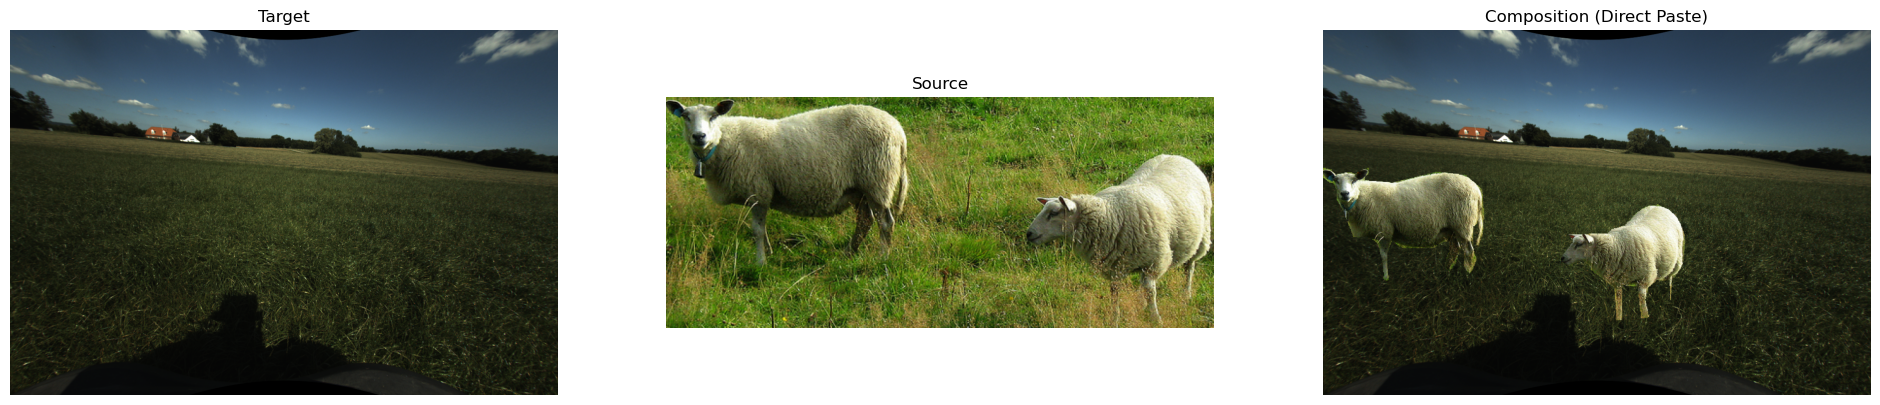

In [98]:
def direct_paste(dest_img, src_img, cropped_source, cropped_mask, centre_x, centre_y):
    
    result = dest_img.copy()

    patch_height, patch_width = src_img.shape[:2]
    dest_height, dest_width = dest_img.shape[:2]

    # centering the patch around the centre
    top_left_x = centre_x - patch_width // 2
    top_left_y = centre_y - patch_height // 2

    valid_top_left_x = max(top_left_x, 0)
    #print(valid_top_left_x)
    valid_top_left_y = max(top_left_y, 0)
    #print(valid_top_left_y)
    valid_bottom_right_x = min(top_left_x + patch_width, dest_width)
    valid_bottom_right_y = min(top_left_y + patch_height, dest_height)

    #print(valid_bottom_right_y-valid_top_left_y, valid_bottom_right_x-valid_top_left_x)
    #print(cropped_mask.shape)
    #print(cropped_source.shape)

    ## ADD HERE
    result[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x] = np.where(
            cropped_mask[..., None] == 1,
            cropped_source,
            result[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x]
        )
    
    return result

dcomp_result = direct_paste(dest_img=dest_img, src_img=resized_image, cropped_source=cropped_source, cropped_mask=cropped_mask, centre_x=centre_x, centre_y=centre_y)

#visualise, save
display_images_side_by_side(images=[dest_img, cropped_source, dcomp_result], titles=[f"Target", "Source", "Composition (Direct Paste)"], config_cmap=[None, None, None], save_path=None)

#### Alpha Blending + Feathering

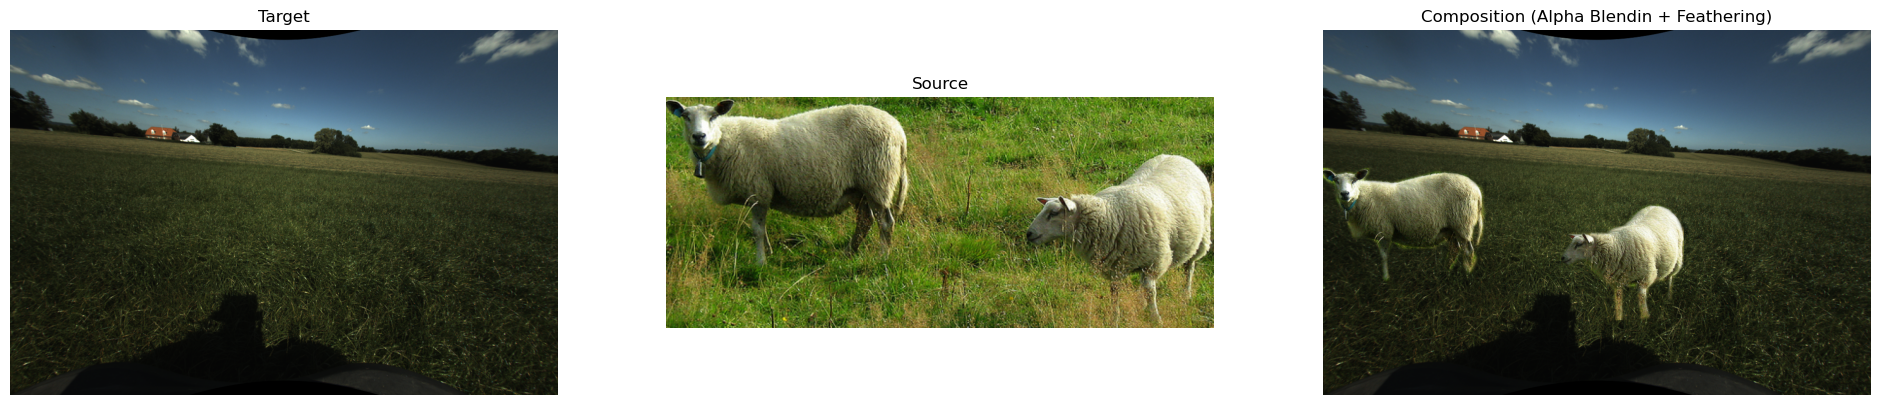

In [99]:
def alpha_blending(dest_img, src_img, cropped_source, cropped_mask, centre_x, centre_y, feather_radius=15):
    
    result = dest_img.copy()

    patch_height, patch_width = cropped_source.shape[:2]
    dest_height, dest_width = dest_img.shape[:2]

    top_left_x = centre_x - patch_width // 2
    top_left_y = centre_y - patch_height // 2

    valid_top_left_x = max(top_left_x, 0)
    valid_top_left_y = max(top_left_y, 0)
    valid_bottom_right_x = min(top_left_x + patch_width, dest_width)
    valid_bottom_right_y = min(top_left_y + patch_height, dest_height)

    cropped_source = cropped_source[:valid_bottom_right_y - valid_top_left_y, :valid_bottom_right_x - valid_top_left_x]
    cropped_mask = cropped_mask[:valid_bottom_right_y - valid_top_left_y, :valid_bottom_right_x - valid_top_left_x]

    # Apply feathering to the mask using Gaussian blur
    feathered_mask = cv2.GaussianBlur(cropped_mask.astype(np.float32), (feather_radius, feather_radius), 0)
    feathered_mask = feathered_mask[..., None]  # Add a channel dimension for broadcasting

    # Perform alpha blending with the feathered mask
    for c in range(3):  # Iterate over the color channels (assuming RGB)
        result[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x, c] = \
            (cropped_source[:, :, c] * feathered_mask[:, :, 0] +
             result[valid_top_left_y:valid_bottom_right_y, valid_top_left_x:valid_bottom_right_x, c] * (1 - feathered_mask[:, :, 0]))
    
    return result

acomp_result = alpha_blending(dest_img=dest_img, src_img=resized_image, cropped_source=cropped_source, cropped_mask=cropped_mask, centre_x=centre_x, centre_y=centre_y, feather_radius=15)

#visualise, save
display_images_side_by_side(images=[dest_img, cropped_source, acomp_result], titles=[f"Target", "Source", "Composition (Alpha Blendin + Feathering)"], config_cmap=[None, None, None], save_path=None)

In [100]:
centre_x, centre_y

(394, 469)

### Poisson Blending

In [101]:
import numpy as np
from PIL import Image
import scipy as sp

def read_image(path_to_image: str, mask_image: bool, scale: bool=False):
    
    img = Image.open(path_to_image)

    if mask_image:
        img = img.convert("L") # greyscale
        binary_mask = np.array(img) > 127
        return binary_mask.astype(np.uint8)

    img = np.array(img.convert('RGB'))
    if scale:
        return img.astype('double') / 255.0

    return img

def apply_clahe_mask(image, mask):

    image_uint8 = (image * 255).clip(0, 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)

    lab = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    l_clahe_full = clahe.apply(l)

    l_clahe = l.copy()
    l_clahe[mask > 0] = l_clahe_full[mask > 0]

    lab_clahe = cv2.merge((l_clahe, a, b))

    result = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    return result

def get_neighbors(i: int, j: int, max_i: int, max_j: int):
    return [(i + di, j) for di in (-1, 1) if 0 <= i + di <= max_i] + \
        [(i, j + dj) for dj in (-1, 1) if 0 <= j + dj <= max_j]
        
def populate_normal(A, b, y_coords, x_coords, pixel_idx_map, src_image_test, dest_image_test, H, W):

    counter = 0
    num_mask_pixels = len(y_coords)

    for index in range(num_mask_pixels):
        y, x = y_coords[index], x_coords[index]

        for ny, nx in get_neighbors(y, x, H-1, W-1):
            A[counter, pixel_idx_map[y][x]] = 1
            
            b[counter] = src_image_test[y][x] - src_image_test[ny][nx]

            if pixel_idx_map[ny][nx] != -1:
                A[counter, pixel_idx_map[ny][nx]] = -1
            else:
                b[counter] += dest_image_test[ny][nx]

            counter += 1
    
    return A, b

def populate_mixed(A, b, y_coords, x_coords, pixel_idx_map, src_image_test, dest_image_test, H, W):

    counter = 0
    num_mask_pixels = len(y_coords)

    for index in range(num_mask_pixels):
        y, x = y_coords[index], x_coords[index]

        for ny, nx in get_neighbors(y, x, H-1, W-1):
            d1 = src_image_test[y][x] - src_image_test[ny][nx]
            d2 = dest_image_test[y][x] - dest_image_test[ny][nx]

            strongest = d1 if abs(d1) > abs(d2) else d2

            A[counter, pixel_idx_map[y][x]] = 1
            
            b[counter] = strongest

            if pixel_idx_map[ny][nx] != -1:
                A[counter, pixel_idx_map[ny][nx]] = -1
            else:
                b[counter] += dest_image_test[ny][nx]

            counter += 1
    
    return A, b

def compute_poisson_blend_channel(src_image_test, dest_image_test, mask, mode):

    H, W = src_image_test.shape

    num_mask_pixels = mask.sum().astype(int)
    pixel_idx_map = np.full(mask.shape, -1, dtype=int)
    y_coords, x_coords = np.where(mask == 1)
    pixel_idx_map[mask > 0] = np.arange(num_mask_pixels)

    A = sp.sparse.lil_matrix((4 * num_mask_pixels, num_mask_pixels))
    b = np.zeros(4 * num_mask_pixels)

    if mode=='normal':

        A, b = populate_normal(A, b, y_coords, x_coords, pixel_idx_map, src_image_test, dest_image_test, H, W)

    if mode=='mixed':
        A, b = populate_mixed(A, b, y_coords, x_coords, pixel_idx_map, src_image_test, dest_image_test, H, W)


    A = sp.sparse.csr_matrix(A)
    v = sp.sparse.linalg.lsqr(A, b)[0]

    copy_dest = dest_image_test.copy()

    for index in range(num_mask_pixels):
        y, x = y_coords[index], x_coords[index]
        copy_dest[y][x] = v[pixel_idx_map[y][x]]

    
    return np.clip(copy_dest, 0, 1)

In [31]:
#display_images_side_by_side(images=[dest_img, placement_image, placement_mask], titles=[f"Target", f"Source", f"Mask"], config_cmap=[None, None, 'grey'], save_path=None)

In [102]:
pcomp_result_initial = np.dstack([
    compute_poisson_blend_channel(placement_image[:, :, c]/255., dest_img[:, :, c]/255., placement_mask, mode='normal')
    for c in range(3)
])

pcomp_result = apply_clahe_mask(pcomp_result_initial, placement_mask)

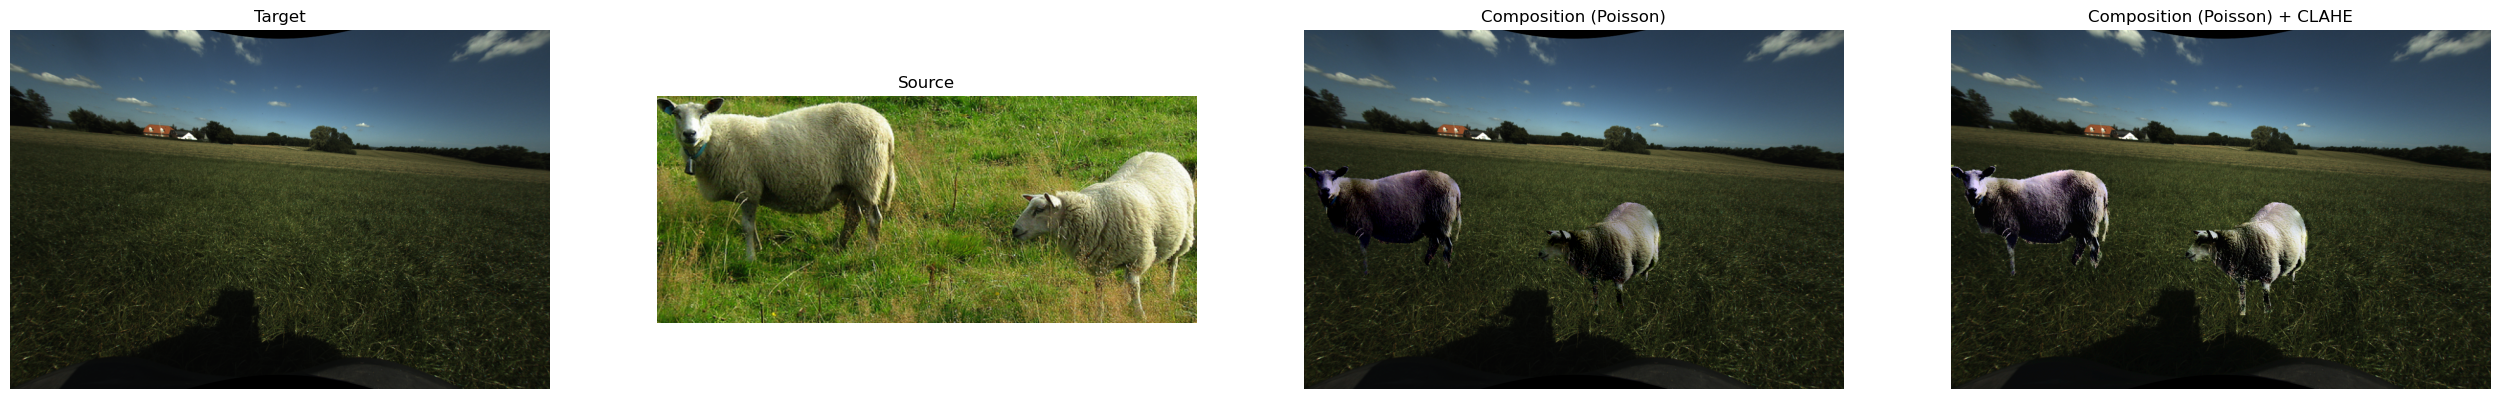

In [103]:
display_images_side_by_side(images=[dest_img, cropped_source, pcomp_result_initial, pcomp_result], titles=[f"Target", "Source", "Composition (Poisson)","Composition (Poisson) + CLAHE"], config_cmap=[None, None, None, None], save_path=None)

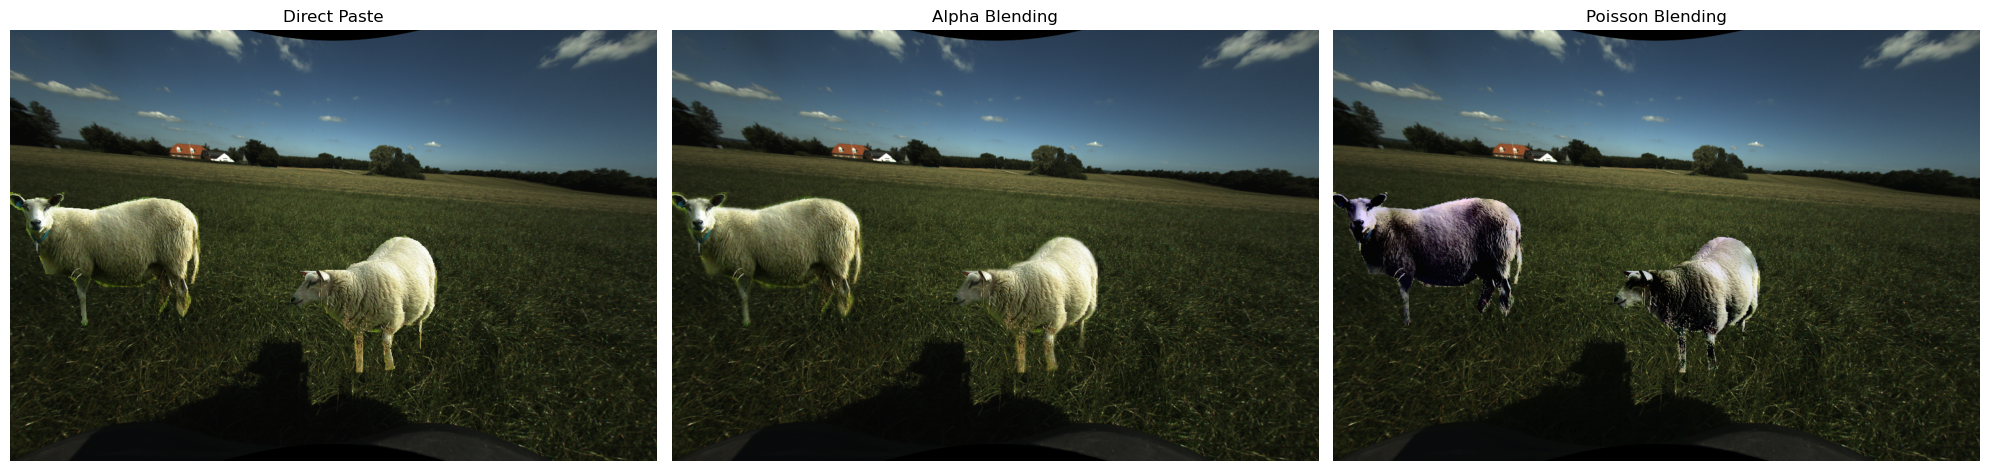

In [104]:
images = [dcomp_result, acomp_result, pcomp_result]
titles = ["Direct Paste", "Alpha Blending", "Poisson Blending"]

plt.figure(figsize=(20, 5))  

for i, (image, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(1, 3, i)  
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')  

plt.tight_layout()  
plt.show()

In [105]:
## testing things Poisson..
from skimage import exposure
import cv2
import numpy as np

def histogram_match(source, blended):
    matched = exposure.match_histograms(blended, source, channel_axis=-1)
    return matched

histogram_pcomp_result = histogram_match(placement_image, pcomp_result)


def colour_correct(source, target, mask):
    source_mean = cv2.mean(source, mask=mask)[:3]

    blended_mean = cv2.mean(target, mask=mask)[:3]

    diff = np.array(source_mean) - np.array(blended_mean)

    corrected = target.astype(np.float32)
    corrected[:, :, 0] += diff[0]
    corrected[:, :, 1] += diff[1]
    corrected[:, :, 2] += diff[2]

    corrected = np.clip(corrected, 0, 255).astype(np.uint8)

    return corrected

colour_pcom_result = colour_correct(placement_image, pcomp_result, placement_mask)


def luminance_transfer(source, blended):
    source_lab = cv2.cvtColor(source, cv2.COLOR_BGR2LAB)
    blended_lab = cv2.cvtColor(blended, cv2.COLOR_BGR2LAB)

    blended_lab[:, :, 0] = source_lab[:, :, 0]

    corrected = cv2.cvtColor(blended_lab, cv2.COLOR_LAB2BGR)

    return corrected

luminance_pcom_result = luminance_transfer(placement_image, pcomp_result)

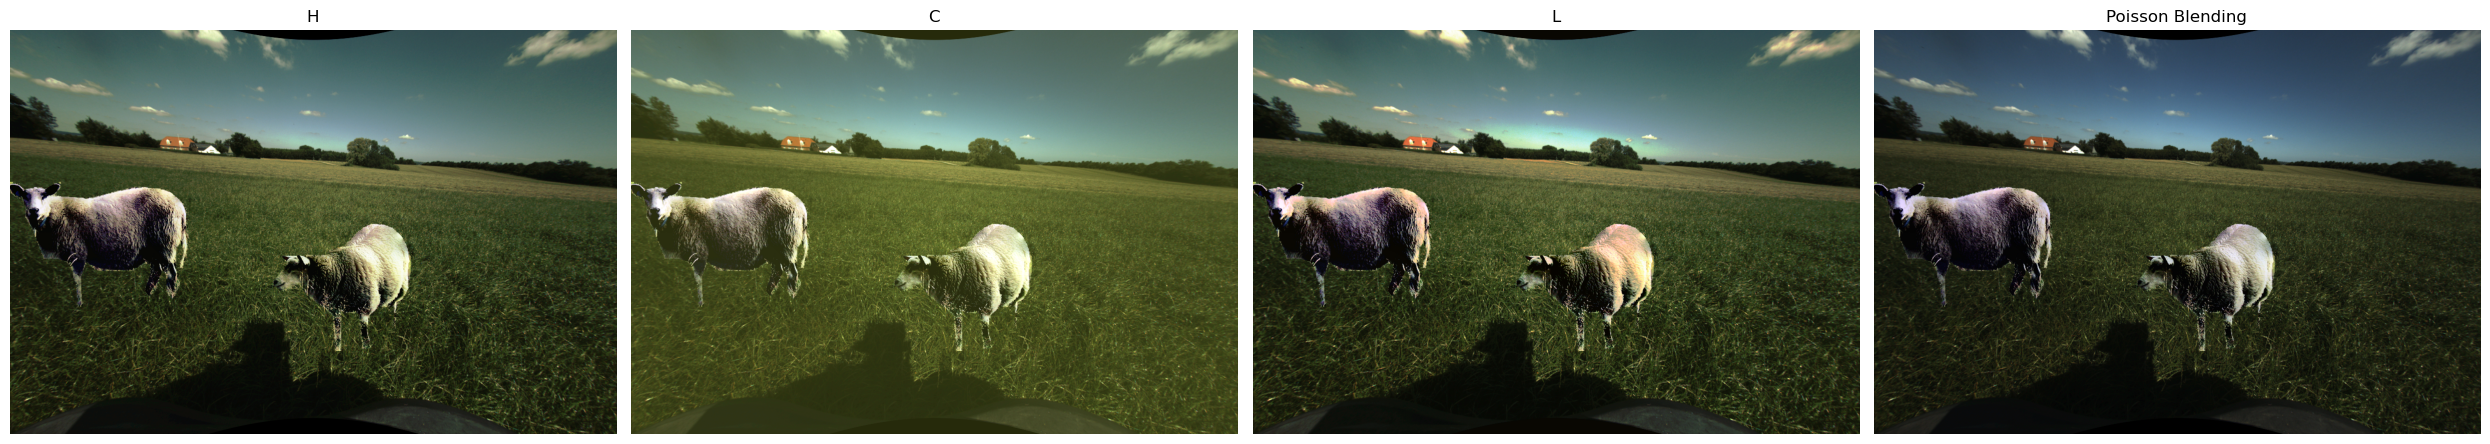

In [106]:
images = [histogram_pcomp_result, colour_pcom_result, apply_clahe_mask(  histogram_match(placement_image, pcomp_result_initial), placement_mask), pcomp_result]
titles = ["H", "C", "L","Poisson Blending"]

plt.figure(figsize=(25, 5))  

for i, (image, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(1, 4, i)  
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')  

plt.tight_layout()  
plt.show()
